# Student Depression Prediction Project  
Tuwaiq Academy

> **Big idea:** This project aims to understand student lifestyle and academic factors and identify whether a student may be at risk of depression.

**My plan (Project Workflow):**

1. Load dataset
2. Understand the dataset and columns  
3. Clean the data (missing values)&Feature Engineering
4. Explore one column at a time (distributions)
5. Categorical Features 
6. Relationships with Depression
7. Correlation Heatmap  
8. Outlier Analysis  
9. Data Cleaning for ML  
10. Preprocessing
11. PCA
12. Modeling
13. Model Evaluation
14. Compare Model Results
15. Confusion Matrix
16. ROC Curve
17. Save the Best Model
18. Test One Prediction
19. Final Insights
20. Conclusion

## Import Libraries

In this step, we import the libraries needed for data analysis, visualization, preprocessing, machine learning modeling, PCA, and model evaluation.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    RocCurveDisplay
)

import joblib

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

print("Libraries loaded successfully!")

Libraries loaded successfully!


## 1. Load Dataset

In this step, we load the Student Depression dataset and display the first few rows to understand the structure of the data.

In [2]:
df = pd.read_csv("student_lifestyle_100k.csv")

df.head()

,Student_ID,Age,Gender,Department,CGPA,Sleep_Duration,Study_Hours,Social_Media_Hours,Physical_Activity,Stress_Level,Depression
0,1001,22,Female,Science,3.50,7.3,3.3,3.4,114,5,False
1,1002,20,Male,Engineering,2.72,5.5,7.2,6.0,142,2,False
2,1003,20,Male,Medical,3.01,5.4,2.3,1.8,137,3,False
3,1004,21,Male,Engineering,3.63,8.1,2.0,4.6,130,3,False
4,1005,19,Male,Arts,3.14,6.8,2.6,4.3,4,6,False


## 2. Understand the dataset and columns  

Here, we check the number of rows and columns, column names, data types, and basic information about the dataset.

In [3]:
#show how many rows and columns
print("Shape (rows, columns):", df.shape)
print("\nColumn names:")
#show all columns names
print(df.columns.tolist())

Shape (rows, columns): (100000, 11)

Column names:
['Student_ID', 'Age', 'Gender', 'Department', 'CGPA', 'Sleep_Duration', 'Study_Hours', 'Social_Media_Hours', 'Physical_Activity', 'Stress_Level', 'Depression']


In [4]:
# function shows the data type of each column and whether there are missing values
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 11 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   Student_ID          100000 non-null  int64  
 1   Age                 100000 non-null  int64  
 2   Gender              100000 non-null  str    
 3   Department          100000 non-null  str    
 4   CGPA                100000 non-null  float64
 5   Sleep_Duration      100000 non-null  float64
 6   Study_Hours         100000 non-null  float64
 7   Social_Media_Hours  100000 non-null  float64
 8   Physical_Activity   100000 non-null  int64  
 9   Stress_Level        100000 non-null  int64  
 10  Depression          100000 non-null  bool   
dtypes: bool(1), float64(4), int64(4), str(2)
memory usage: 7.7 MB


In [5]:
# gives statistics for the columns like mean and min and max
df.describe()

,Student_ID,Age,CGPA,Sleep_Duration,Study_Hours,Social_Media_Hours,Physical_Activity,Stress_Level
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,51000.500000,21.009010,2.898316,6.996425,4.509517,3.503288,74.353180,4.131660
std,28867.657797,2.000382,0.532240,1.498682,1.976076,1.486852,43.366963,1.424151
min,1001.000000,18.000000,1.560000,3.000000,0.000000,0.000000,0.000000,2.000000
25%,26000.750000,19.000000,2.450000,6.000000,3.200000,2.500000,37.000000,3.000000
50%,51000.500000,21.000000,2.900000,7.000000,4.500000,3.500000,74.000000,4.000000
75%,76000.250000,23.000000,3.350000,8.000000,5.800000,4.500000,112.000000,5.000000
max,101000.000000,24.000000,4.000000,12.000000,12.800000,10.000000,149.000000,10.000000


Understand the target 
It tells us whether the student is at risk of depression True or not False. I check its distribution to see if the classes are balanced.

In [6]:
#Show us how many students are (True = Probable Depression, False = Healthy)
df["Depression"].value_counts()

Depression
False    89938
True     10062
Name: count, dtype: int64

I use the plot to makes the target distribution easier to understand visually because that important if the data is imbalanced the accuracy is not enough to evaluate the model

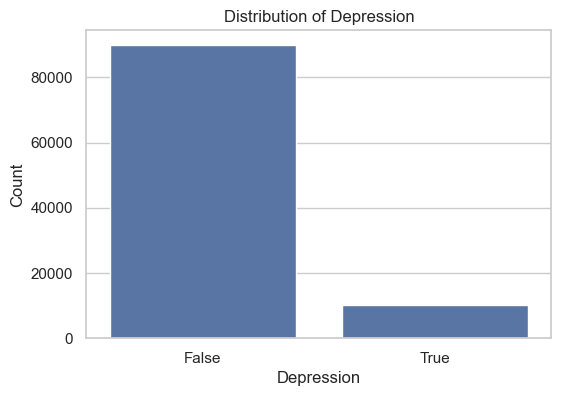

In [7]:
#(True = Probable Depression, False = Healthy)
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="Depression")
plt.title("Distribution of Depression")
plt.xlabel("Depression")
plt.ylabel("Count")
plt.show()

From this bar graph we can see that most of the students are doesn't have depression and nearly 10000 students are suffering from depression
This indicates that the dataset is **imbalanced**, so I should not model evaluation depend on only on accuracy but also on Precision, Recall, F1-score, and ROC-AUC.

## 3. Clean the data (missing values)&Feature Engineering
Clean the data and fixed missing values and create new feature

In [8]:
# Show us how many values are missing in each column
missing_values = df.isnull().sum().sort_values(ascending=False)
missing_values

Student_ID            0
Age                   0
Gender                0
Department            0
CGPA                  0
Sleep_Duration        0
Study_Hours           0
Social_Media_Hours    0
Physical_Activity     0
Stress_Level          0
Depression            0
dtype: int64

All columns contain complete information with no missing values.

In [9]:
# Count how many duplicate rows
df.duplicated().sum()

np.int64(0)

The dataset doesn't contains duplicate rows

## Feature Engineering
I created a copy of the dataset before feature engineering to keep the original dataset unchanged and make the workflow safer and more organized.
And i crate new feature from existing data to improve data understanding and potentially enhance machine learning model performance

In [10]:
# I make a copy of my data df_fe
df_fe = df.copy()

# I change the physical activity from minutes to hours
df_fe["Physical_Activity_Hours"] = df_fe["Physical_Activity"] / 60
# I create new feature
# try to measure Lifestyle_Balance, student with high Lifestyle_Balance have healthier daily habits
df_fe["Lifestyle_Balance"] = (
    df_fe["Study_Hours"] +
    df_fe["Physical_Activity_Hours"] -
    df_fe["Social_Media_Hours"]
)
# Measure good hours of the student
df_fe["Productive_Hours"] = (
    df_fe["Study_Hours"] +
    df_fe["Physical_Activity_Hours"]
)
# Measure the overall academic pressure experienced by a student.
df_fe["Stress_Study"] = (
    df_fe["Stress_Level"] * 
    df_fe["Study_Hours"]
)

df_fe.head()

,Student_ID,Age,Gender,Department,CGPA,Sleep_Duration,Study_Hours,Social_Media_Hours,Physical_Activity,Stress_Level,Depression,Physical_Activity_Hours,Lifestyle_Balance,Productive_Hours,Stress_Study
0,1001,22,Female,Science,3.50,7.3,3.3,3.4,114,5,False,1.900000,1.800000,5.200000,16.5
1,1002,20,Male,Engineering,2.72,5.5,7.2,6.0,142,2,False,2.366667,3.566667,9.566667,14.4
2,1003,20,Male,Medical,3.01,5.4,2.3,1.8,137,3,False,2.283333,2.783333,4.583333,6.9
3,1004,21,Male,Engineering,3.63,8.1,2.0,4.6,130,3,False,2.166667,-0.433333,4.166667,6.0
4,1005,19,Male,Arts,3.14,6.8,2.6,4.3,4,6,False,0.066667,-1.633333,2.666667,15.6


- **Lifestyle_Balance** measures the balance between productive activities and social media usage.
- **Productive_Hours** estimates the total productive time spent on studying and physical activity.
- **Stress_Study** represents the combined effect of stress level and study hours.

## 4. Explore one column at a time (distributions)
I explore the distribution of some of numerical feature to understand the data patterns before modeling.

Age Distribution

This plot shows the distribution of student ages in the dataset.

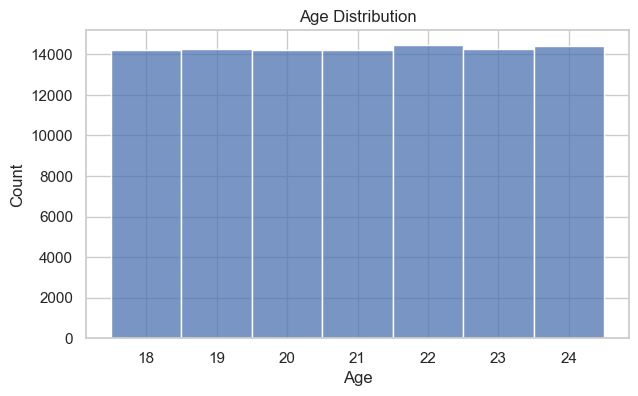

In [11]:
plt.figure(figsize=(7,4))
sns.histplot(df_fe["Age"], discrete=True)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

The dataset includes students between **18 and 24 years old**, and the age distribution is fairly balanced across all age groups. This suggests that no single age dominates the dataset making it suitable for comparing depression patterns across different ages.

CGPA Distribution

This plot shows how students CGPA values are distributed.

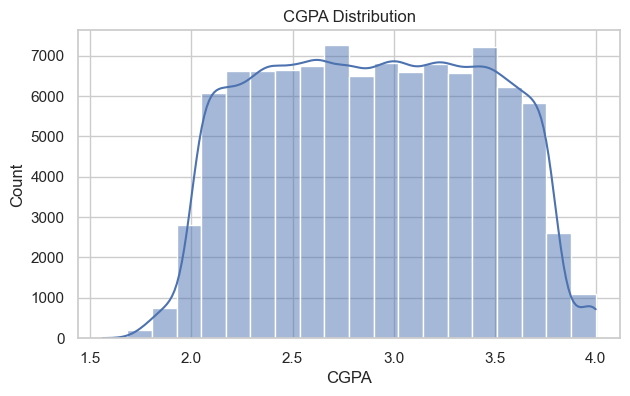

In [12]:
plt.figure(figsize=(7, 4))
sns.histplot(df_fe["CGPA"], bins=20, kde=True)
plt.title("CGPA Distribution")
plt.xlabel("CGPA")
plt.ylabel("Count")
plt.show()

The distribution is relatively balanced and the CGPA distribution covers a wide range of academic performance with most students having a CGPA between 2.0 and 3.7

Sleep Duration Distribution

This plot shows the distribution of students sleep duration.

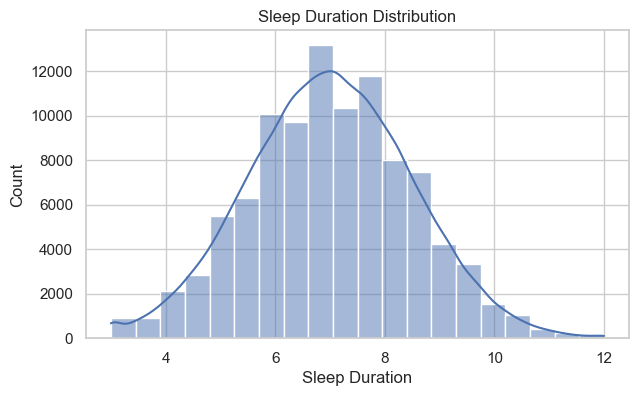

In [13]:
plt.figure(figsize=(7, 4))
sns.histplot(df_fe["Sleep_Duration"], bins=20, kde=True)
plt.title("Sleep Duration Distribution")
plt.xlabel("Sleep Duration")
plt.ylabel("Count")
plt.show()

Most of the students sleep between 6 to 8 hours and the distribution appears approximately normal making sleep duration a useful feature for further analysis with depression.

Study Hours Distribution

This plot shows how many hours students are studying.

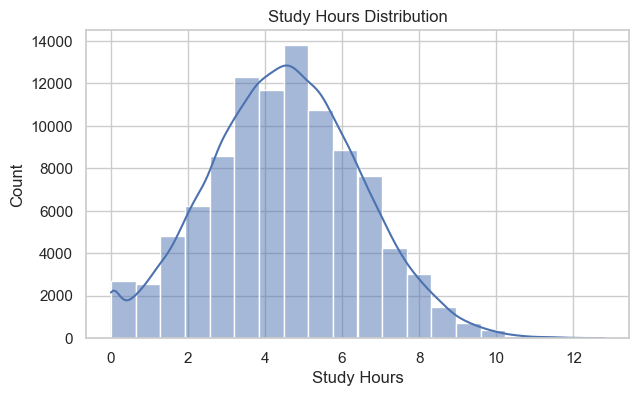

In [14]:
plt.figure(figsize=(7, 4))
sns.histplot(df_fe["Study_Hours"], bins=20, kde=True)
plt.title("Study Hours Distribution")
plt.xlabel("Study Hours")
plt.ylabel("Count")
plt.show()

Most of the students study between 3 and 6 hours per day and the distribution is almost normal

## 5. Categorical Features

Gender Distribution

This plot shows the number of students in each gender category.

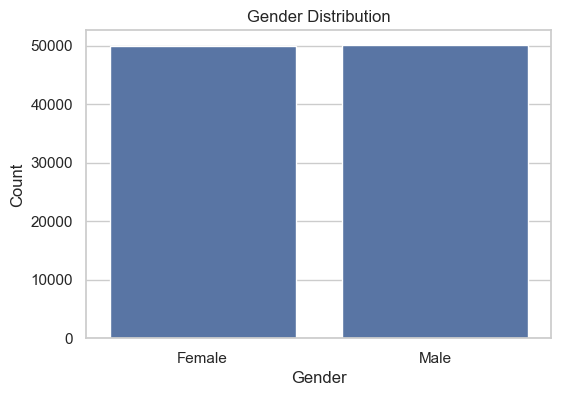

In [15]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df_fe, x="Gender")
plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.show()

The dataset contains an almost equal number of male and female students. This balanced gender distribution helps reduce potential gender bias during data analysis and machine learning modelingز

Department Distribution

This plot shows the number of students in each department.

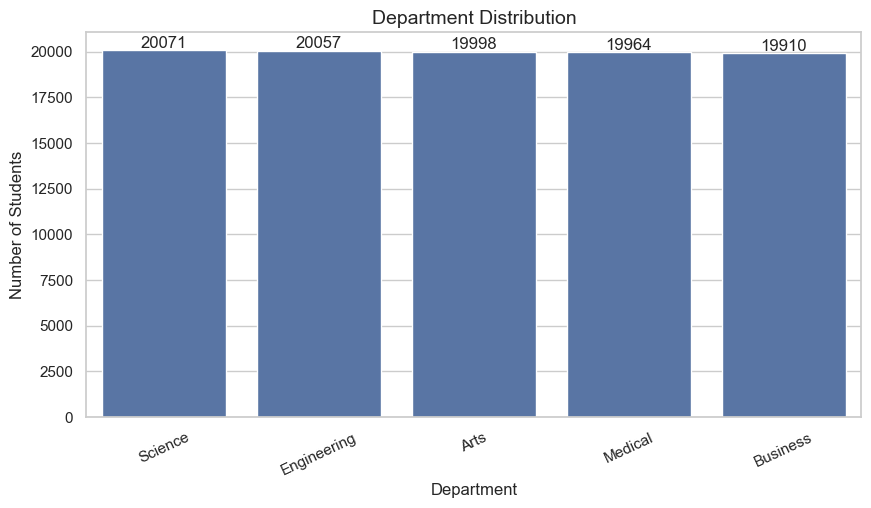

In [16]:
plt.figure(figsize=(10,5))

ax = sns.countplot(
    data=df_fe,
    x="Department",
    order=df_fe["Department"].value_counts().index
)

plt.title("Department Distribution", fontsize=14)
plt.xlabel("Department")
plt.ylabel("Number of Students")
plt.xticks(rotation=25)

# يضيف اعداداهم فوق
for container in ax.containers:
    ax.bar_label(container)

plt.show()

The number of students is almost equally distributed across the five departments: Science.This balanced distribution indicates that no single department  will effect more then other of the dataset. 

## 6. Relationships with Depression

CGPA by Depression

This plot compares CGPA between healthy students and students with probable depression.

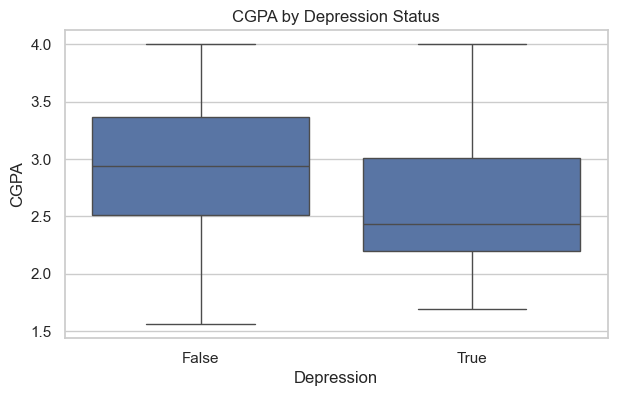

In [17]:
plt.figure(figsize=(7, 4))
sns.boxplot(data=df_fe, x="Depression", y="CGPA")
plt.title("CGPA by Depression Status")
plt.xlabel("Depression")
plt.ylabel("CGPA")
plt.show()

The median CGPA is higher for students without probable depression than for students with probable depression. And both groups have overlapping CGPA values the plot suggests a possible negative relationship between depression and academic performance.

Sleep Duration by Depression

This plot compares sleep duration between depression groups.

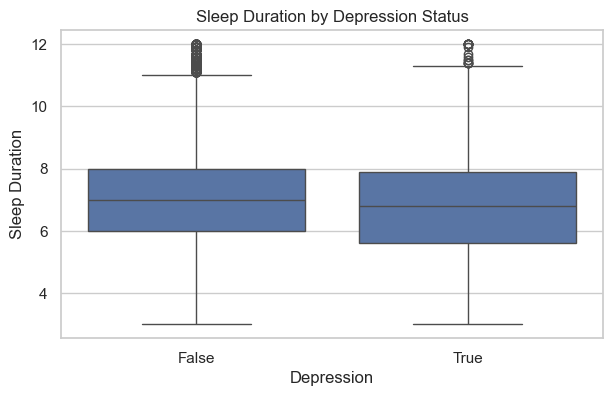

In [18]:
plt.figure(figsize=(7, 4))
sns.boxplot(data=df_fe, x="Depression", y="Sleep_Duration")
plt.title("Sleep Duration by Depression Status")
plt.xlabel("Depression")
plt.ylabel("Sleep Duration")
plt.show()

Students without probable depression have a slightly higher median sleep duration than students with probable depression. ِAnd the large overlap between the two groups suggests that sleep duration alone is not a strong indicator of depression.

Study Hours by Depression

This plot compares study hours between depression groups.

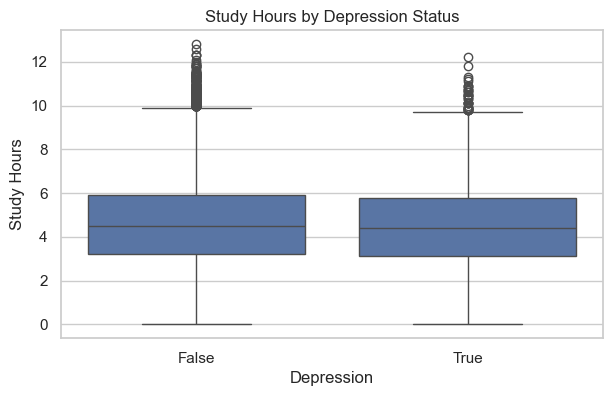

In [19]:
plt.figure(figsize=(7, 4))
sns.boxplot(data=df_fe, x="Depression", y="Study_Hours")
plt.title("Study Hours by Depression Status")
plt.xlabel("Depression")
plt.ylabel("Study Hours")
plt.show()

Students with and without probable depression have similar study hour distributions. The large overlap between the two groups suggests that study hours alone are not a strong indicator of depression.

Social Media Hours by Depression

This plot compares social media usage between depression groups.

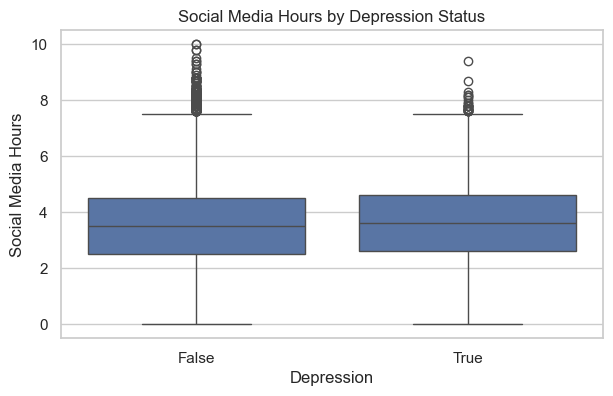

In [20]:
plt.figure(figsize=(7, 4))
sns.boxplot(data=df_fe, x="Depression", y="Social_Media_Hours")
plt.title("Social Media Hours by Depression Status")
plt.xlabel("Depression")
plt.ylabel("Social Media Hours")
plt.show()

Students with probable depression (True) show a slightly higher median of social media usage compared to students without probable depression (False).And the distributions overlap.

Stress Level by Depression

This plot compares stress levels between depression groups.

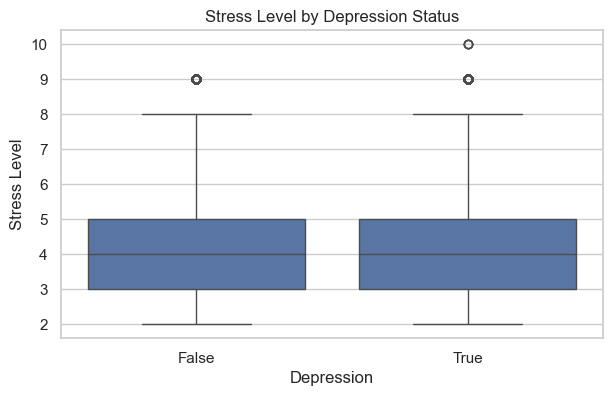

In [21]:
plt.figure(figsize=(7, 4))
sns.boxplot(data=df_fe, x="Depression", y="Stress_Level")
plt.title("Stress Level by Depression Status")
plt.xlabel("Depression")
plt.ylabel("Stress Level")
plt.show()

The stress level distributions for students with and without probable depression are very similar. Both groups have the same median stress level (around 4) and a comparable spread of values.

## 7. Correlation Heatmap

This heatmap shows the correlation between numerical features.

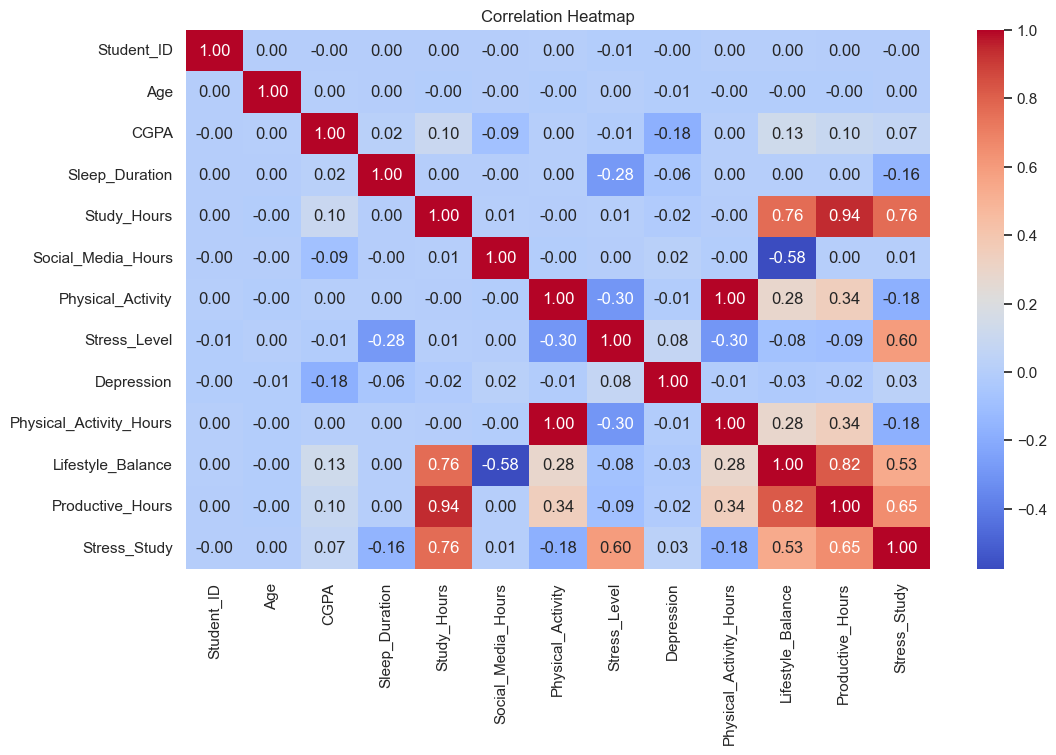

In [22]:
numeric_df = df_fe.select_dtypes(include=["int64", "float64", "bool"])

plt.figure(figsize=(12, 7))
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

The correlation heatmap shows that most original features have weak linear correlations with the target variable (Depression) indicating that no single feature alone strongly explains depression.

And the features engineered  Productive_Hours has a very strong positive correlation with Study_Hours (0.94), while Lifestyle_Balance is also strongly correlated with Productive_Hours(0.82). These strong correlations are expected because these features were created from the original variables.

## 8. Outlier Analysis

CGPA Outliers

This boxplot checks for possible outliers in CGPA.

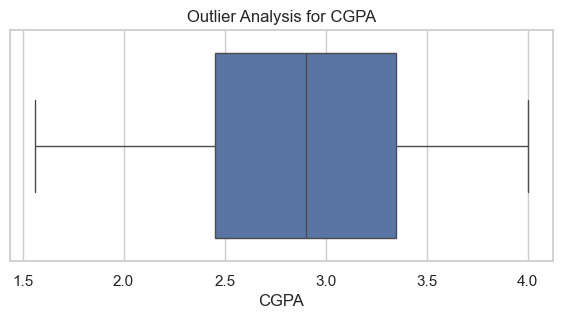

In [29]:
plt.figure(figsize=(7, 3))
sns.boxplot(x=df_fe["CGPA"])
plt.title("Outlier Analysis for CGPA")
plt.xlabel("CGPA")
plt.show()

The CGPA distribution does not contain significant outliers.

Sleep Duration Outliers

This boxplot checks for possible outliers in Sleep Duration.

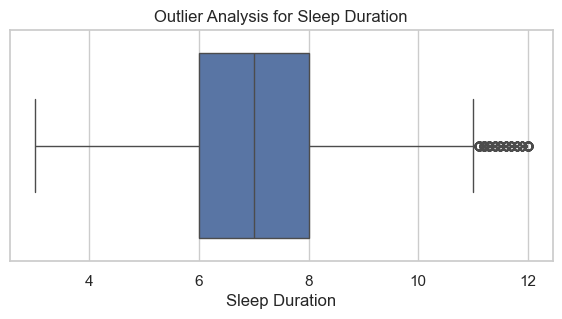

In [30]:
plt.figure(figsize=(7, 3))
sns.boxplot(x=df_fe["Sleep_Duration"])
plt.title("Outlier Analysis for Sleep Duration")
plt.xlabel("Sleep Duration")
plt.show()

Most students sleep around 6–8 hours per day. A small number of students sleep more than 11 hours showing as outliers. 

Study Hours Outliers

This boxplot checks for possible outliers in Study Hours.

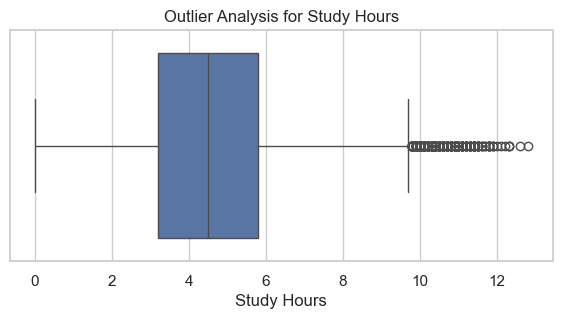

In [31]:
plt.figure(figsize=(7, 3))
sns.boxplot(x=df_fe["Study_Hours"])
plt.title("Outlier Analysis for Study Hours")
plt.xlabel("Study Hours")
plt.show()

Most students study around 3–6 hours per day and a small number of students study more than 10 hours showing as outliers.

Social Media Hours Outliers

Checks for possible outliers in Social Media Hours.

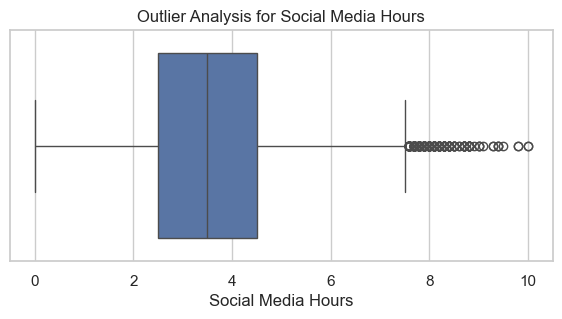

In [32]:
plt.figure(figsize=(7, 3))
sns.boxplot(x=df_fe["Social_Media_Hours"])
plt.title("Outlier Analysis for Social Media Hours")
plt.xlabel("Social Media Hours")
plt.show()

Most students spend around 2.5–4.5 hours on social media each day. A small number of students use social media for more than 7.5 hours and showing as outliers.

Physical Activity Hours Outliers

This boxplot checks for possible outliers in Physical Activity Hours.

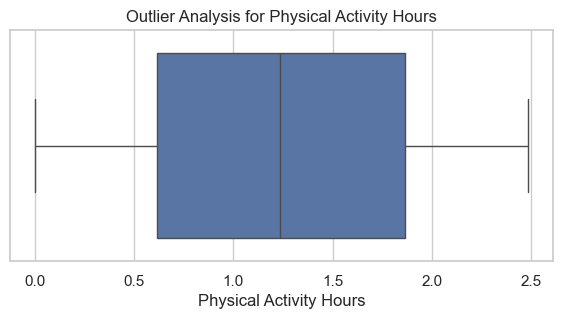

In [33]:
plt.figure(figsize=(7, 3))
sns.boxplot(x=df_fe["Physical_Activity_Hours"])
plt.title("Outlier Analysis for Physical Activity Hours")
plt.xlabel("Physical Activity Hours")
plt.show()

Physical activity hours do not have significant outliers. Most students spend around 0.6–1.9 hours per day on physical activityز

Stress Level Outliers

Checks for possible outliers in Stress Level.

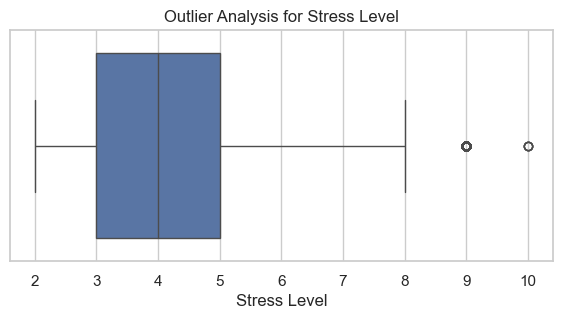

In [34]:
plt.figure(figsize=(7, 3))
sns.boxplot(x=df_fe["Stress_Level"])
plt.title("Outlier Analysis for Stress Level")
plt.xlabel("Stress Level")
plt.show()

Most students have a stress level between 3 and 5 and a few students report very high stress levels (9–10) showing as outliers.

## 9. Data Cleaning for ML

In [ ]:
df_ml = df_fe.copy()

df_ml = df_ml.drop_duplicates()
# i drop Student_ID because no need and  Physical_Activity because i have what i create Physical_Activity_Hours
df_ml = df_ml.drop(columns=["Student_ID", "Physical_Activity"])

print("Shape after cleaning:", df_ml.shape)
df_ml.head()

Shape after cleaning: (100000, 13)


,Age,Gender,Department,CGPA,Sleep_Duration,Study_Hours,Social_Media_Hours,Stress_Level,Depression,Physical_Activity_Hours,Lifestyle_Balance,Productive_Hours,Stress_Study
0,22,Female,Science,3.50,7.3,3.3,3.4,5,False,1.900000,1.800000,5.200000,16.5
1,20,Male,Engineering,2.72,5.5,7.2,6.0,2,False,2.366667,3.566667,9.566667,14.4
2,20,Male,Medical,3.01,5.4,2.3,1.8,3,False,2.283333,2.783333,4.583333,6.9
3,21,Male,Engineering,3.63,8.1,2.0,4.6,3,False,2.166667,-0.433333,4.166667,6.0
4,19,Male,Arts,3.14,6.8,2.6,4.3,6,False,0.066667,-1.633333,2.666667,15.6


## 10. Preprocessing
Machine learning models work numerical input.  
- I change Depression from True/False to 1/0.
- Numerical columns will be scaled using StandardScaler.
- Categorical columns will be encoded using OneHotEncoder.

In [36]:
X = df_ml.drop("Depression", axis=1)

# False = 0 Healthy
# True = 1 Probable Depression
y = df_ml["Depression"].astype(int)

print(y.value_counts())

Depression
0    89938
1    10062
Name: count, dtype: int64


In [38]:
#حولت الانواع الى ارقام وتصنيفات عشان استخدمها
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns
categorical_features = X.select_dtypes(include=["object", "category"]).columns

print("Numeric Features:", list(numeric_features))
print("Categorical Features:", list(categorical_features))

Numeric Features: ['Age', 'CGPA', 'Sleep_Duration', 'Study_Hours', 'Social_Media_Hours', 'Stress_Level', 'Physical_Activity_Hours', 'Lifestyle_Balance', 'Productive_Hours', 'Stress_Study']
Categorical Features: ['Gender', 'Department']


C:\Users\SA\AppData\Local\Temp\ipykernel_7592\350376084.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X.select_dtypes(include=["object", "category"]).columns


In [ ]:
#هنا قسمنا البيانات لتدريب وللاختبار  وعشان نحفظ البيانات من اللكيج التسرب
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (80000, 12)
X_test: (20000, 12)
y_train: (80000,)
y_test: (20000,)


In [41]:
#نوحد الاعمده الرقميه ويكون متوسط كل عمود 0 والانحراف المعياري 1
numeric_transformer = StandardScaler()
#حولت الاعمده النصيه الى اعمده رقميه 0 و1
categorical_transformer = OneHotEncoder(
    #هذا اذا واجه تصنيف حديد يتجاهله ومايعيط خطا
    handle_unknown="ignore",
    #يرجع البيانات مصفوفه عاديه
    sparse_output=False
)
#دمج عمليات البري بروسيسنق 
preprocessor = ColumnTransformer(
    transformers=[
        #نطبق على جميع الاعمدة الرقميه StandardScaler 
        ("num", numeric_transformer, numeric_features),
        #نطبق على كل الاعمده النصيه OneHotEncoder 
        ("cat", categorical_transformer, categorical_features)
    ]
)

## 11. PCA

PCA is used to reduce the number of features while keeping most of the important information.  

I check how many components are needed to explain 90% of the variance.

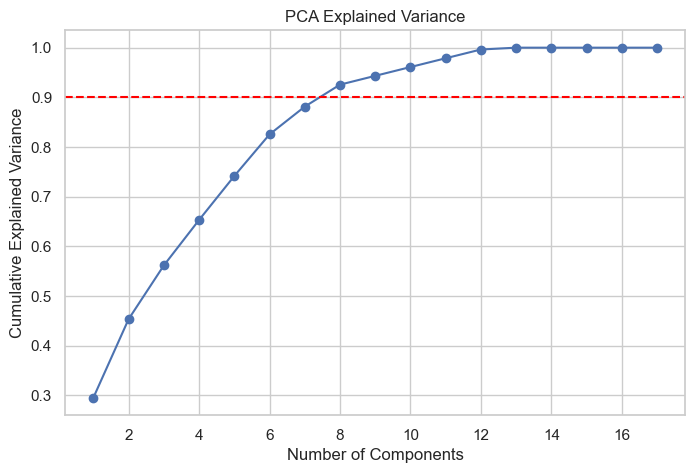

Number of components needed for 90% variance: 8


In [42]:
X_train_processed = preprocessor.fit_transform(X_train)

pca = PCA()
X_train_pca = pca.fit_transform(X_train_processed)

cumulative = np.cumsum(pca.explained_variance_ratio_)

plt.figure(figsize=(8, 5))
plt.plot(range(1, len(cumulative) + 1), cumulative, marker="o")
plt.axhline(0.90, color="red", linestyle="--")
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Explained Variance")
plt.show()

n_90 = np.argmax(cumulative >= 0.90) + 1
print("Number of components needed for 90% variance:", n_90)

## 12. Modeling

I will train three classification models:

1. Logistic Regression  
2. Random Forest  
3. Logistic Regression with PCA  

These models are suitable for binary classification.

In [43]:
log_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000, class_weight="balanced"))
])

log_model.fit(X_train, y_train)

y_pred_log = log_model.predict(X_test)
y_prob_log = log_model.predict_proba(X_test)[:, 1]

In [63]:
rf_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=100,
        max_depth=10,
        min_samples_leaf=2,
        random_state=42,
        class_weight="balanced"
    ))
])

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

In [45]:
pca_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("pca", PCA(n_components=0.90)),
    ("classifier", LogisticRegression(max_iter=1000, class_weight="balanced"))
])

pca_model.fit(X_train, y_train)

y_pred_pca = pca_model.predict(X_test)
y_prob_pca = pca_model.predict_proba(X_test)[:, 1]

## 13. Model Evaluation

Because there is imbalanced and binary classification problem i will evaluate the models using:

- Accuracy
- Precision
- Recall
- F1-score
- ROC-AUC

In [64]:
def evaluate_model(name, y_test, y_pred, y_prob):
    print(name)
    print("Accuracy:", round(accuracy_score(y_test, y_pred), 4))
    print("Precision:", round(precision_score(y_test, y_pred), 4))
    print("Recall:", round(recall_score(y_test, y_pred), 4))
    print("F1-score:", round(f1_score(y_test, y_pred), 4))
    print("ROC-AUC:", round(roc_auc_score(y_test, y_prob), 4))
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

In [65]:
evaluate_model("Logistic Regression", y_test, y_pred_log, y_prob_log)

Logistic Regression
Accuracy: 0.6183
Precision: 0.1617
Recall: 0.6675
F1-score: 0.2603
ROC-AUC: 0.6792

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.61      0.74     17988
           1       0.16      0.67      0.26      2012

    accuracy                           0.62     20000
   macro avg       0.55      0.64      0.50     20000
weighted avg       0.86      0.62      0.69     20000



In [66]:
evaluate_model("Random Forest", y_test, y_pred_rf, y_prob_rf)

Random Forest
Accuracy: 0.7352
Precision: 0.217
Recall: 0.6257
F1-score: 0.3223
ROC-AUC: 0.7022

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.75      0.84     17988
           1       0.22      0.63      0.32      2012

    accuracy                           0.74     20000
   macro avg       0.58      0.69      0.58     20000
weighted avg       0.87      0.74      0.78     20000



In [67]:
evaluate_model("Logistic Regression with PCA", y_test, y_pred_pca, y_prob_pca)

Logistic Regression with PCA
Accuracy: 0.618
Precision: 0.162
Recall: 0.6705
F1-score: 0.261
ROC-AUC: 0.6799

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.61      0.74     17988
           1       0.16      0.67      0.26      2012

    accuracy                           0.62     20000
   macro avg       0.55      0.64      0.50     20000
weighted avg       0.86      0.62      0.69     20000



## 14. Compare Model Results

This table show the compares all models using the main classification metrics.

In [68]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "Logistic Regression + PCA"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred_log),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_pca)
    ],
    "Precision": [
        precision_score(y_test, y_pred_log),
        precision_score(y_test, y_pred_rf),
        precision_score(y_test, y_pred_pca)
    ],
    "Recall": [
        recall_score(y_test, y_pred_log),
        recall_score(y_test, y_pred_rf),
        recall_score(y_test, y_pred_pca)
    ],
    "F1-score": [
        f1_score(y_test, y_pred_log),
        f1_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_pca)
    ],
    "ROC-AUC": [
        roc_auc_score(y_test, y_prob_log),
        roc_auc_score(y_test, y_prob_rf),
        roc_auc_score(y_test, y_prob_pca)
    ]
})

results

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Logistic Regression,0.61835,0.161671,0.667495,0.260297,0.679184
1,Random Forest,0.73525,0.217032,0.625746,0.322283,0.702153
2,Logistic Regression + PCA,0.61800,0.162023,0.670477,0.260979,0.679868


Among the three models Random Forest achieved the best overall performance. It obtained the highest Accuracy (73.5%), Precision (21.7%), F1-score (0.322), and ROC-AUC (0.702) and indicating a better balance between correctly identifying students with probable depression and minimizing incorrect predictions.

Although Logistic Regression and Logistic Regression + PCA achieved slightly higher Recall and their overall performance was lower due to weaker Precision and F1-score. And Random Forest was selected as the best model because it provided the best overall balance across the evaluation metrics.

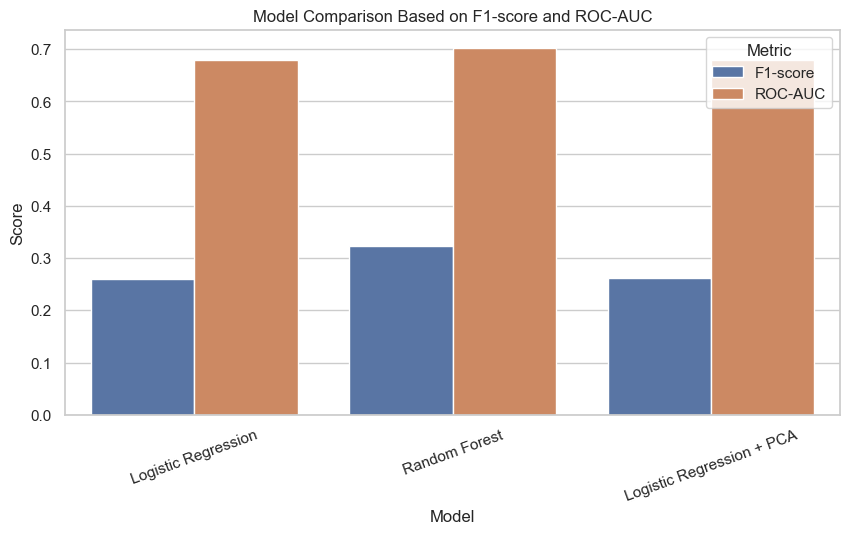

In [69]:
results_melted = results.melt(
    id_vars="Model",
    value_vars=["F1-score", "ROC-AUC"],
    var_name="Metric",
    value_name="Score"
)

plt.figure(figsize=(10, 5))
sns.barplot(data=results_melted, x="Model", y="Score", hue="Metric")
plt.title("Model Comparison Based on F1-score and ROC-AUC")
plt.xticks(rotation=20)
plt.show()

Random Forest outperformed the other models by achieving the highest Accuracy, Precision, F1-score, and ROC-AUC. And Logistic Regression + PCA achieved a slightly higher Recall and Random Forest provided the best overall balance between detecting probable depression and reducing incorrect predictions.Random Forest was selected as the best model.

## 15. Confusion Matrix

The confusion matrix shows the number of correct and incorrect predictions for each class.

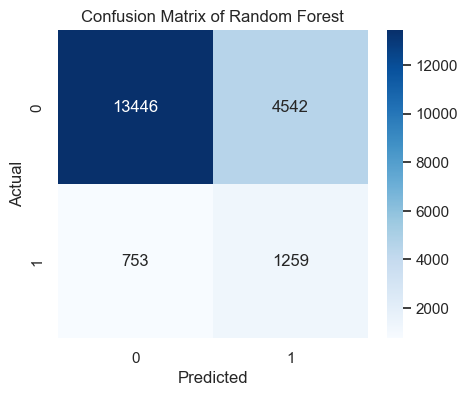

In [70]:
cm = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix of Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

The Random Forest model correctly identified most healthy students and successfully detected 1,259 students with probable depression. And  the model generated some false positive predictions it significantly reduced the number of missed depression cases and making it more suitable for early depression detection.

## 16. ROC Curve

The ROC curve shows how well the model separates the two classes.

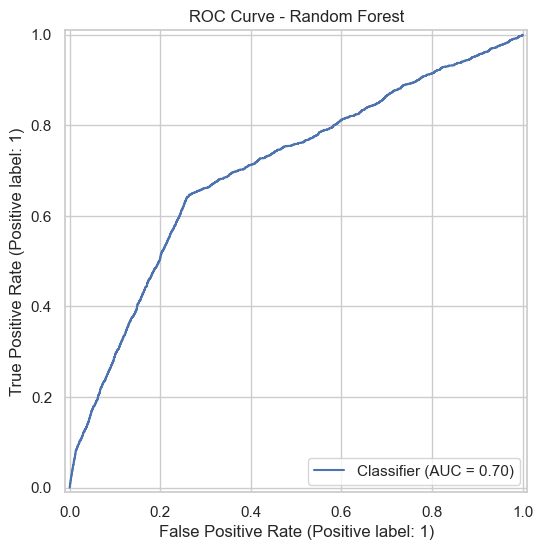

In [71]:
RocCurveDisplay.from_predictions(y_test, y_prob_rf)
plt.title("ROC Curve - Random Forest")
plt.show()

The Random Forest model achieved a ROC-AUC of 0.70 and indicating good discrimination between healthy students and students with probable depression. The model performs better than random guessing and demonstrates reliable classification performance.

## 17. Save the Best Model

In [72]:
best_model = rf_model

joblib.dump(best_model, "best_student_depression_model.pkl")

print("Best model saved successfully.")

Best model saved successfully.


## 18. Test One Prediction

In [73]:
sample = X_test.iloc[[0]]

prediction = best_model.predict(sample)[0]
probability = best_model.predict_proba(sample)[0][1]

print("Prediction:", prediction)
print("Probability of probable depression:", round(probability, 4))

if prediction == 1:
    print("Result: Probable Depression")
else:
    print("Result: Healthy")

Prediction: 0
Probability of probable depression: 0.3526
Result: Healthy


## 19. Final Insights

- The dataset was clean and required minimal preprocessing.
- Feature engineering created meaningful variables that improved the representation of students' lifestyle and study behavior.
- EDA showed noticeable differences in CGPA and social media usage between healthy students and students with probable depression.
- PCA reduced the feature space while preserving 90% of the original information using 8 principal components.
- Among the three evaluated models the Random Forest achieved the best overall performance with the highest Accuracy, F1-score, and ROC-AUC.
- Random Forest was selected as the final model for predicting student depression and was used for deployment in the Streamlit application.

## 20. Conclusion

This project analyzed a large student lifestyle dataset to predict probable depression using machine learning techniques. The analysis included data exploration, feature engineering, preprocessing, dimensionality reduction with PCA, and the evaluation of multiple classification models.

The Exploratory Data Analysis (EDA) provided valuable insights into the dataset and highlighted patterns related to students' academic performance and lifestyle. Feature engineering further improved the representation of student behavior by creating meaningful variables such as Lifestyle_Balance, Productive_Hours, and Stress_Study.

Three machine learning models were evaluated: Logistic Regression,Random Forest, and Logistic Regression with PCA. Based on the evaluation metrics, Random Forest achieved the best overall performance, with the highest Accuracy, F1-score, and ROC-AUC, making it the most suitable model for this classification task.

Finally, the selected model was saved for deployment and integrated into a Streamlit application, allowing users to enter student information and predict the probability of depression using the trained machine learning model.

In [ ]:
#عشان الشخص في الستريم ليت يكون قادر يختار اي مودل 
joblib.dump(log_model, "logistic_model.pkl")

joblib.dump(rf_model, "random_forest_model.pkl")

joblib.dump(pca_model, "logistic_pca_model.pkl")

print("All models saved successfully.")

All models saved successfully.
